In [1]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
import pandas as pd
from scipy.stats import zscore

print(os.getcwd())

/data/cmn_vamal/mwilson/gene-sgan


In [2]:
folder_path = "/data/cmn_vamal/mwilson/new_data/new_data_folder/nii_folder/fsl_processing_outputs/"

for filename in os.listdir(folder_path):
    if filename.endswith("fast_restore.nii.gz"):
        filepath = os.path.join(folder_path, filename)
        img = nib.load(filepath)
        data = img.get_fdata()

x = []
for filename in os.listdir(folder_path):
    if filename.endswith("fast_restore.nii.gz"):
        x.append(filename.split("_fast_restore.nii.gz")[0])
x = np.array(x)
xy = pd.DataFrame({"filename": x, "pca_raw_cluster": y})


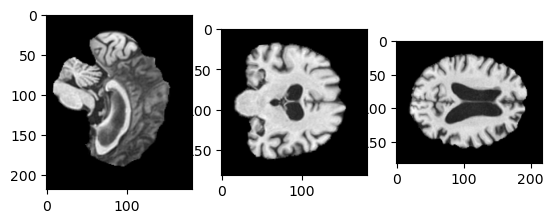

Full image shape: (182, 218, 182)


In [14]:
img = nib.load(filepath)
data = img.get_fdata()

fig, axes = plt.subplots(1, 3)
axes[0].imshow(data[data.shape[0]//2, :, :], cmap='gray')
axes[1].imshow(data[:, data.shape[1]//2, :], cmap='gray')
axes[2].imshow(data[:, :, data.shape[2]//2], cmap='gray')
plt.show()



In [ ]:
x_start, x_end = 30, 170
y_start, y_end = 20, 160
z_start, z_end = 20, 150

data_matrix = []
filenames = []

for filename in os.listdir(folder_path):
    if filename.endswith("fast_restore.nii.gz"):
        filepath = os.path.join(folder_path, filename)
        img = nib.load(filepath)
        data = img.get_fdata()
        
        cropped = data[x_start:x_end, y_start:y_end, z_start:z_end]
        data_matrix.append(cropped.flatten())
        filenames.append(filename)
data_matrix = np.array(data_matrix)
print(f"Original shape: {data.shape}")
print(f"Cropped shape: {cropped.shape}")
print(f"Data matrix shape: {data_matrix.shape}")

In [32]:
os.chdir("/data/cmn_vamal/mwilson/new_data/new_data_folder/nii_folder/Imbalanced-Data-Clustering-using-Equilibrium-K-Means/python")
import ekm_sklearn
from ekm_sklearn import EKM
ekm = EKM(n_clusters=3, random_state=0, alpha='dvariance', scale=2.0, tol = 1e-3).fit(data_matrix)
y = (ekm.labels_)

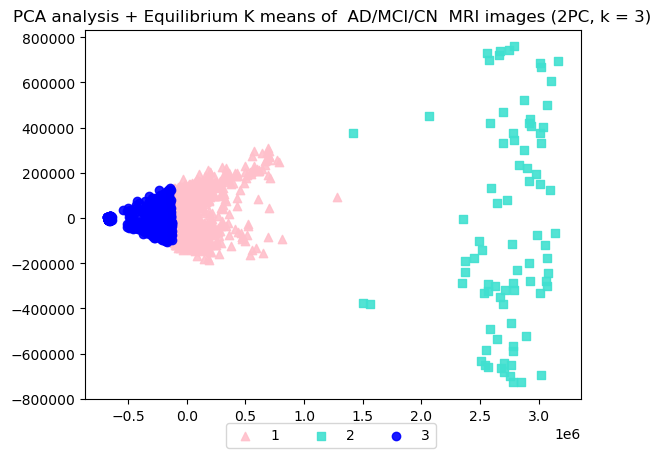

In [33]:
for i in range(1):
    fig, ax = plt.subplots()
    pca = PCA(n_components=4,random_state=42)
    pca_result = pca.fit_transform(data_matrix)
    for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
        ax.scatter(pca_result[y == l, 0],
                    pca_result[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
    plt.title(f"PCA analysis + Equilibrium K means of  AD/MCI/CN  MRI images (2PC, k = 3)")
    labels = [1,2,3]
    fig.legend(labels, loc='lower center',ncol=len(labels))
    plt.show()

In [66]:
merged = pd.merge(xy, final_metadata, on='filename', how='inner')
final_metadata = pd.read_csv("/data/cmn_vamal/mwilson/new_metadata/final_metadata.csv")
final_metadata = final_metadata.iloc[:,[1,2,3]]

a = merged.iloc[:,[3]]
y = merged.iloc[:,[1]]

for i in range(len(merged)):
    if a.iloc[i,0] == "CN":
        a.iloc[i,0] = 0
    elif a.iloc[i,0] == "MCI":
        a.iloc[i,0] = 1
    else: 
        a.iloc[i,0] = 2

a.iloc[:,0] = a.iloc[:,0].astype(int)
accuracy_score(a, y)

/tmp/ipykernel_768773/4243059515.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a.iloc[i,0] = 0
/tmp/ipykernel_768773/4243059515.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a.iloc[i,0] = 2
/tmp/ipykernel_768773/4243059515.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a.iloc[i,0] = 1
/tmp/ipykernel_768773/4243059515.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

0.25556792873051226